In [1]:
from sklearn.datasets import fetch_covtype
from dataloading import prepare_data
from utils import train_iteratively, uncertainty
import plots
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

# Load dataset

In [2]:
cov_type = fetch_covtype()
np.unique_counts(cov_type["target"]).counts

array([211840, 283301,  35754,   2747,   9493,  17367,  20510])

# Plot class imbalance  

In [3]:
def plot_downsampled_distribution(data):
    plt.subplot(2, 2, 1)
    plots.plot_class_distribution(cov_type["target"], "Original", show = False)

    plt.subplot(2, 2, 2)
    plots.plot_class_distribution(data['train']['y'], "Train", show = False)

    plt.subplot(2, 2, 3)
    plots.plot_class_distribution(data['pool']['y'], "Pool", show = False)

    plt.subplot(2, 2, 4)
    plots.plot_class_distribution(data['test']['y'], "Test", show = False)

    plt.suptitle("Class distributions")
    plt.tight_layout()
    plt.show()


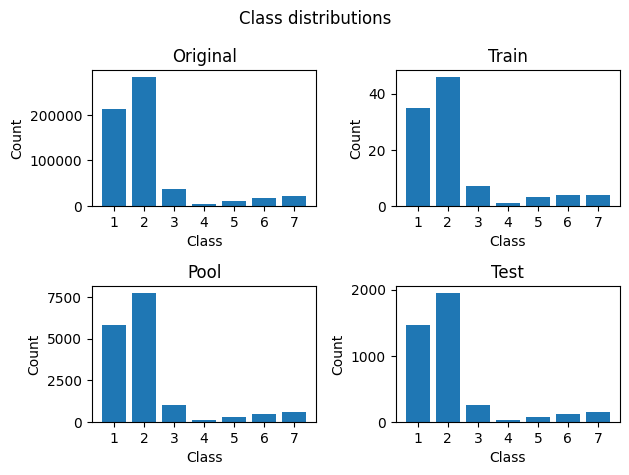

In [4]:
data,explained_var = prepare_data(
    cov_type,
    n_init=100,
    n_points=20000,   # optional (set None to use full dataset)
    seed=42,
    even_distribution=False
)
plot_downsampled_distribution(data)

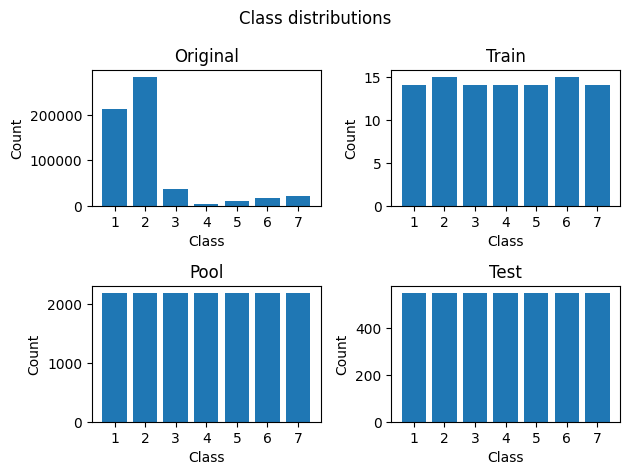

In [5]:
data,explained_var = prepare_data(
    cov_type,
    n_init=100,
    n_points=20000,   # optional (set None to use full dataset)
    seed=42,
    even_distribution=True
)

plot_downsampled_distribution(data)

# Train the model

In [16]:
data,explained_var = prepare_data(
    cov_type,
    n_init=14,
    n_points=20000,   # optional (set None to use full dataset)
    seed=42,
    even_distribution=True
)

model = LogisticRegression(solver='lbfgs', max_iter=400)

#test_acc_random = train_iteratively(data, model, "random", 20, 5)
test_acc, test_acc_byclass = train_iteratively(data, model, "random",addn=5,iterations=50)


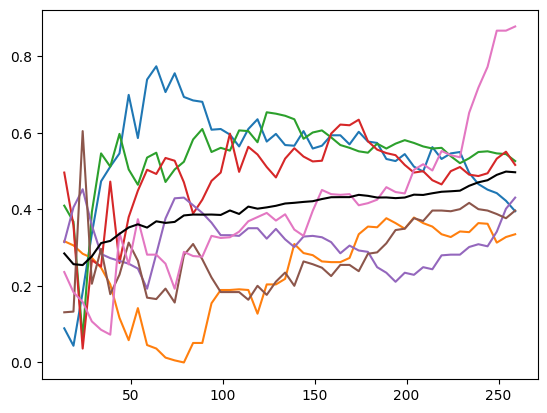

In [18]:
for clas in range(7):
    plt.plot([x[0] for x in test_acc_byclass[clas]], [x[1] for x in test_acc_byclass[clas]])
plt.plot([x[0] for x in test_acc], [x[1] for x in test_acc], color = "k")